In [2]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [ ]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
#folder_path = filedialog.askdirectory(title='Select input folder')
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=200, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")


If pop up box not seen minimise spyder and select folder wanted for analysis


In [ ]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink
c3= '#744db0' # purple

GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

In [ ]:
#----Configuring folders needed----
# number of rows in txt files to skip
rows = 3
DATASET_MAP = {
    'Unpass_1': {'parent': 'Unpassivated', 'type': '250422_CTRL_RG0087', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_2': {'parent': 'Unpassivated', 'type': '250513_CTRL_RG0087', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_3': {'parent': 'Unpassivated', 'type': '250519_CTRL_RG0087', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_4': {'parent': 'Unpassivated', 'type': '251103_CTRL_RG0093', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Pass_1': {'parent': 'Passivated', 'type': '250506_AEAPTMS_RG0089', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_2': {'parent': 'Passivated', 'type': '250520_AEAPTMS_RG0089', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_3': {'parent': 'Passivated', 'type': '251023_AEAPTMS_RG0094', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_4': {'parent': 'Passivated', 'type': '251023_AEAPTMS_RG0094_2', 'colour1': "#D69AAB", 'colour2': "#8D1730"}
}

In [ ]:
# --- Directory Selection Functions ---

def select_root_path():
    """Opens a single dialog to select the top-level ROOT_PATH."""
    root_path = filedialog.askdirectory(title='Select the Top-Level ROOT_PATH Folder')
    if not root_path:
        print("No root path selected. Exiting.")
        return None
    return root_path

In [ ]:
#Single Gaussian Fitting

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [ ]:
def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - A_fit: Amplitude of the fitted Gaussian
    - mu_fit: Mean (center) of the fitted Gaussian
    - sigma_fit: Standard deviation (width) of the fitted Gaussian
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        min_raw=np.min(x_data)
        mean_raw=np.mean(x_data)
        max_raw=np.max(x_data)
        # Print the fitted parameters for feedback
        #print(f"Fitted parameters:\nAmplitude: {A_fit}\nMean: {mu_fit}\nSigma: {sigma_fit}")
        #print(f"Raw data parameters are:\n Min = {min_raw}\n Mean = {mean_raw}\n Max = {max_raw}")
       
        # Return the fitted parameters and covariance matrix
        return A_fit, mu_fit, sigma_fit, popt, pcov

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

In [ ]:
# Gaussian fitting (Multigaussian) 
# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [ ]:
# --- Gaussian fitting---
def fit_gaussian (file_path, rows):
    """Performs Gaussian fitting on data from a given file path."""
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)
        
    x_data = data[:, 0]
    y_data = data[:, 1]
    
    # Estimate initial guess and peak count (Assumes estimate_guess_from_data is defined) 
    #for multigaussian
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    '''#initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    #popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
    #y_fit=multi_gaussian(x_fit,*popt)
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    fwhm = 2.355 * highest['wid']'''

    #For single gaussian: 
    A, mu, sigma, popt, pcov = fit_gaussian_from_dataset(x_data, y_data)
    y_fit=gaussian(x_fit,*popt)
    
    peak_index_max=np.argmax(y_fit)
    peak_centre=x_fit[peak_index_max]
    
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    fwhm = 2.355 * highest['wid']
    
    return x_data, y_data, x_fit, y_fit, peak_centre, fwhm

In [ ]:
#Specific grain boundary function
def grain_boundaries(GB_file_path, GI_file_path, pixel_index, save_path, GB_colour='input', GI_colour='input'):
    """
    Fits Gaussian to GB and GI data, plots the results, saves the plot, 
    and writes the analysis data to a text file.
    """
    # Pixel number corresponds to the 'pixels' value (1 to 5)
    pixels = pixel_index 
    #Plotting parameters
    figsize_x, figsize_y = 3.5, 2.5 
    tick_length = 4 
    legend_font = 10 
    scatter_size = 15 
    base_font_size = 10
    line_width = 1.5
    # Perform fitting
    GB_x_raw_1, GB_y_raw_1, GB_x_1, GB_y_1, GB_peak_1, GB_fwhm_1 = fit_gaussian(GB_file_path, rows)
    GI_x_raw_1, GI_y_raw_1, GI_x_1, GI_y_1, GI_peak_1, GI_fwhm_1 = fit_gaussian(GI_file_path, rows)
    
    #Working out peak difference (GI-GB)
    peak_diff_1 = GI_peak_1 - GB_peak_1

    # Plotting functions: 
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size}) # Use a slightly smaller font for general text
    
    ax.tick_params(direction='in', length=tick_length, labelsize=base_font_size)
    ax.tick_params(axis='both')#, labelsize=18)
    ax.margins(0.05, 0.05) # Reduced margins for a tighter plot
    ax.set_xlabel(f"CPD (mV)")#, fontsize=22)
    
    # Calculate limits from all fitted data for consistent scaling
    x_data_all = np.concatenate([GB_x_raw_1, GB_x_1, GI_x_raw_1, GI_x_1])
    ax.set_xlim(np.min(x_data_all) - 0.01, np.max(x_data_all) + 0.01)
    ax.set_ylabel("Distribution (V$^{-1}$)")#, fontsize=22)
    
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    
    # Plotting
    plt.scatter(GB_x_raw_1, GB_y_raw_1, label=f"GB", color=GB_colour, s=scatter_size)
    plt.plot(GB_x_1, GB_y_1, label=f"_nolegend_", color=GB_colour, linewidth=line_width)
    plt.scatter(GI_x_raw_1, GI_y_raw_1, label=f"GI", color=GI_colour, s=scatter_size, marker='s')
    plt.plot(GI_x_1, GI_y_1, label=f"_nolegend_", color=GI_colour, linewidth=line_width, linestyle='--')
    
    plt.legend(loc='upper right', fontsize=legend_font)
    
    # Save Plot
    # Assumes save_plot_to_folder is defined and handles the saving
    fig=plt.gcf()
    plot_filename = f'GrainBoundary_Interior_MultiGaussian_{pixels*20}_nm.jpeg'
    save_plot_to_folder(fig, save_path, filename=plot_filename)
    plt.close(fig) # Close figure to prevent memory issues

    # Save Analysis Output
    output_file = os.path.join(save_path, f'GrainBoundaries_analysis_output_{pixels*20}_nm.txt')
    with open(output_file, 'w') as f:
        output_lines = [
            f"Analysis for {pixels*20} nm:",
            "Grain boundary peak = " + str(GB_peak_1),
            "Grain boundary fwhm = " + str(GB_fwhm_1),
            "Grain interior peak = " + str(GI_peak_1),
            "Grain interior fwhm = " + str(GI_fwhm_1),
            "Diff of GB/GI =" + str(peak_diff_1),
        ]
        for line in output_lines:
            f.write(line + '\n')
            
    return peak_diff_1, GB_peak_1, GI_peak_1

In [ ]:
def GB_diff_processing_final(root_path, dataset_key):
    """
    Processes all 5 pixel files for a given dataset using the fixed file structure:
    ROOT_PATH/parent/type/GB/1.txt
    """
    if not root_path:
        return [np.nan] * 5

    config = DATASET_MAP[dataset_key]
    parent_folder = config['parent']
    type_folder = config['type']
    colour1 = config['colour1']
    colour2 = config['colour2']

    print(f"\n--- Processing: {dataset_key} ---")

    # 1. Define the base folder containing GB/GI subfolders
    # This path is: ROOT_PATH/unpassivated/Dark_CPD
    base_data_folder = os.path.join(root_path, parent_folder, type_folder)
    
    # 2. Define the exact GB and GI folders
    GB_folder = os.path.join(base_data_folder, 'GB')
    GI_folder = os.path.join(base_data_folder, 'GI')
    
    # 3. Define the save path for intermediate plots and text files
    # This will be: ROOT_PATH/Plots/unpassivated/Dark_CPD
    save_path = os.path.join(root_path, 'Plots', parent_folder, type_folder)
    os.makedirs(save_path, exist_ok=True) # Create folder if it doesn't exist

    y_peaks = []
    GB_peaks = []
    GI_peaks = []
    
    # Check if the necessary folders exist before starting the loop
    if not os.path.isdir(GB_folder) or not os.path.isdir(GI_folder):
        print(f"Error: Could not find 'GB' and/or 'GI' folders at {base_data_folder}. Skipping.")
        return [np.nan] * 5

    # 4. Iterate through the 5 pixel files (1 to 5)
    for pixel_index in range(1, 6):
        
        # Construct the file paths: e.g., .../GB/1.txt and .../GI/1.txt
        file_name = f'{pixel_index}.txt'
        GB_file_path = os.path.join(GB_folder, file_name)
        GI_file_path = os.path.join(GI_folder, file_name)
        #print(GB_file_path)
        #print(GI_file_path)
        if os.path.exists(GB_file_path) and os.path.exists(GI_file_path):
            print(f"  Processing Pixel {pixel_index}...")
            peak_diff, GB_peak, GI_peak = grain_boundaries(
                GB_file_path, 
                GI_file_path, 
                pixel_index, 
                save_path, 
                colour1, 
                colour2
            )
            y_peaks.append(peak_diff)
            GB_peaks.append(GB_peak)
            GI_peaks.append(GI_peak)
        else:
            print(f"  File(s) not found for Pixel {pixel_index}. Skipping.")
            print(f"{GB_file_path}")
            y_peaks.append(np.nan) 
            GB_peaks.append(np.nan)
            GI_peaks.append(np.nan)

    # Convert peak differences to mV and round
    y_peaks_adjusted = [round(x * 1000, 4) if not np.isnan(x) else np.nan for x in y_peaks]
    GB_peaks_adjusted = [round(x * 1000, 4) if not np.isnan(x) else np.nan for x in GB_peaks]
    GI_peaks_adjusted = [round(x * 1000, 4) if not np.isnan(x) else np.nan for x in GI_peaks]
    return y_peaks_adjusted, GB_peaks_adjusted, GI_peaks_adjusted

In [ ]:
#Averaging and errors: 
def averaging_for_mean(set1, set2, set3,set4): 
    std_error = []
    data = []
    if len(set1)==len(set2)==len(set3):
        for x in range(len(set1)): 
            measurements= np.array([set1[x], set2[x], set3[x], set4[x]])
            error = np.std(measurements)/np.sqrt(len(measurements))
            std_error.append(error)
            data.append(np.mean([set1[x], set2[x], set3[x], set4[x]]))
        return data, std_error
    else:
        print('Error all lists not same length')
        return Exception()

In [ ]:
# --- Main Execution Block ---
#Just writing data for scatter plots. Plotting in next block. 

ROOT_PATH = select_root_path()

if ROOT_PATH:
    # Get a list of all dataset keys
    all_datasets = list(DATASET_MAP.keys())
    
    # Initialize dictionary to store results
    all_results = {}
    
    print("\n--- Starting Batch Processing ---")
    
    # Loop through all datasets, calling the processing function
    for dataset_key in all_datasets:
        all_results[dataset_key] = GB_diff_processing_final(ROOT_PATH, dataset_key)

    # Assign results to original variables for summary plotting
    Unpass1, UnpassGB_1, UnpassGI_1= all_results['Unpass_1']
    Unpass2, UnpassGB_2, UnpassGI_2= all_results['Unpass_2']
    Unpass3, UnpassGB_3, UnpassGI_3 = all_results['Unpass_3']
    Unpass4, UnpassGB_4, UnpassGI_4 = all_results['Unpass_4']
    Pass1, PassGB_1, PassGI_1 = all_results['Pass_1']
    Pass2, PassGB_2, PassGI_2 = all_results['Pass_2']
    Pass3, PassGB_3, PassGI_3 = all_results['Pass_3']
    Pass4, PassGB_4, PassGI_4 = all_results['Pass_4']
    #Averaging and finding errors for difference: 
    Unpass_all, Unpass_error = averaging_for_mean(Unpass1, Unpass2, Unpass3, Unpass4)
    UnpassGB, UnpassGB_error = averaging_for_mean(UnpassGB_1, UnpassGB_2, UnpassGB_3, UnpassGB_4)
    UnpassGI, UnpassGI_error = averaging_for_mean(UnpassGI_1, UnpassGI_2, UnpassGI_3, UnpassGI_4)

    Pass_all, pass_error = averaging_for_mean(Pass1, Pass2, Pass3, Pass4)
    PassGB, PassGB_error = averaging_for_mean(PassGB_1, PassGB_2, PassGB_3, PassGB_4)
    PassGI, PassGI_error = averaging_for_mean(PassGI_1, PassGI_2, PassGI_3, PassGI_4)




--- Starting Batch Processing ---

--- Processing: Unpass_1 ---
  Processing Pixel 1...
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/CPD_Final/CPD_ForProcessing\Plots\Unpassivated\250422_CTRL_RG0087\GrainBoundary_Interior_MultiGaussian_20_nm.jpeg
  Processing Pixel 2...
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/CPD_Final/CPD_ForProcessing\Plots\Unpassivated\250422_CTRL_RG0087\GrainBoundary_Interior_MultiGaussian_40_nm.jpeg
  Processing Pixel 3...
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/CPD_Final/CPD_ForProcessing\Plots\Unpassivated\250422_CTRL_RG0087\GrainBoundary_Interior_MultiGaussian_60_nm.jpeg
  Processing Pixel 4...
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs

In [ ]:
# --- Summary Plotting ---
   
print("\n--- Summary Plotting ---")
FINAL_PLOTS_SAVE_PATH = filedialog.askdirectory(title='Select Folder to Save All Final Summary Plots')

 # --- Summary Plotting ---
x_nm = [20, 40, 60, 80, 100]

 

#Plotting parameters for easy adjustment
errorbar_capsize = 8
e_linewidth = 1
figsize_x, figsize_y = 3.5, 2.5 
tick_length = 4 
legend_font = 10 
scatter_size = 15 
base_font_size = 10
line_width = 1.5
# 1. Difference CPD plots
plt.figure(figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size})
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')
plt.xlabel("GB width (nm)")
plt.ylabel("GI - GB (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
#plt.scatter(x_nm, Unpass_all, label='Unpassivated', color='#8D1730', marker='o', s=100)
#plt.scatter(x_nm, Pass_all, label='Passivated', color='#003357', marker='^', s=100)
plt.errorbar(x_nm, Unpass_all, yerr = Unpass_error, fmt = '-', capsize=errorbar_capsize, elinewidth=e_linewidth, capthick =e_linewidth, label='Unpassivated', color=GI_U_color, marker='o', markersize=scatter_size, ls = '')
plt.errorbar(x_nm, Pass_all, yerr= pass_error,fmt = '-', capsize=errorbar_capsize, elinewidth=e_linewidth, capthick =e_linewidth, label='Passivated', color=GI_P_color, marker='^', markersize=scatter_size, ls = '')
plt.legend(loc='best', fontsize=legend_font)
plt.tight_layout()
save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='Difference_CPD_Average_both_witherror.jpeg')
plt.show()

# 1. Difference CPD plots
plt.figure(figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size})
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')#, labelsize=18)
plt.xlabel("GB width (nm)")#, fontsize=20)
plt.ylabel("GI - GB (mV)")#, fontsize=20)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
#plt.scatter(x_nm, Unpass_all, label='Unpassivated', color='#8D1730', marker='o', s=100)
#plt.scatter(x_nm, Pass_all, label='Passivated', color='#003357', marker='^', s=100)
plt.errorbar(x_nm, Unpass_all, yerr = Unpass_error, fmt = '-', capsize=errorbar_capsize, elinewidth=e_linewidth, capthick=e_linewidth, label='Unpassivated', color=GI_U_color, marker='o', markersize=scatter_size, ls = '')
plt.legend(loc='best', fontsize=legend_font)
plt.tight_layout()
save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='Difference_CPD_Average_Unpassivated_witherror.jpeg')
plt.show()

# 3. Difference CPD plots
plt.figure(figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size})
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')
plt.xlabel("GB width (nm)")
plt.ylabel("GI - GB (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
#plt.scatter(x_nm, Unpass_all, label='Unpassivated', color='#8D1730', marker='o', s=100)
#plt.scatter(x_nm, Pass_all, label='Passivated', color='#003357', marker='^', s=100)
plt.errorbar(x_nm, Pass_all, yerr= pass_error,fmt = '-', capsize=errorbar_capsize, elinewidth=e_linewidth, capthick =e_linewidth, label='Passivated', color=GI_P_color, marker='^', markersize=scatter_size, ls = '')
plt.legend(loc='best', fontsize=legend_font)
plt.tight_layout()
save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='Difference_CPD_Average_Passivated_witherror.jpeg')
plt.show()

# 4. GI/GB plots Unpassivated
plt.figure(figsize=(figsize_x, figsize_y))
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')
plt.xlabel("GB width (nm)")
plt.ylabel(" CPD average (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

#plt.scatter(x_nm, UnpassGB, label='Unpassivated GB', color='#8D1730', marker='o', s=50)
#plt.scatter(x_nm, UnpassGI, label='Unpassivated GI', color='#003357', marker='^', s=50)
plt.errorbar(x_nm, UnpassGB,yerr=UnpassGB_error, fmt = '-', capsize=errorbar_capsize, elinewidth=e_linewidth, capthick =e_linewidth, label='Unpassivated GB', color=GB_U_color, marker='o', markersize=scatter_size, ls = '')
plt.errorbar(x_nm, UnpassGI, yerr= UnpassGI_error, fmt = '-', capsize=errorbar_capsize,elinewidth=e_linewidth, capthick =e_linewidth,label='Unpassivated GI', color= GI_U_color, marker='^', markersize=scatter_size, ls = '')
plt.legend(loc = 'best', fontsize=legend_font)
plt.tight_layout()
save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='Separate_GB_GI_CPD_Unpassivated_witherror.jpeg')
plt.show()

# 5. GI/GB Passivated
plt.figure(figsize=(figsize_x, figsize_y))
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')
plt.xlabel("GB width (nm)")
plt.ylabel(" CPD average (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#plt.scatter(x_nm, PassGB, label='Passivated GB', color='#8D1730', marker='o', s=50)
#plt.scatter(x_nm, PassGI, label='Passivated GI', color='#003357', marker='^', s=50)
plt.errorbar(x_nm, PassGB, yerr= PassGB_error,fmt = '-', capsize=errorbar_capsize,elinewidth=e_linewidth, label='Passivated GB', color=GB_P_color, marker='o', markersize=scatter_size, ls = '')
plt.errorbar(x_nm, PassGI, yerr=PassGI_error, fmt = '-', capsize=errorbar_capsize,elinewidth=e_linewidth, label='Passivated GI', color=GI_P_color, marker='^', markersize=scatter_size, ls = '')
plt.legend(loc = 'best', fontsize=legend_font)
plt.tight_layout()
save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='Separate_GB_GI_CPD_Passivatd_witherror.jpeg')
plt.show()


--- Summary Plotting ---


KeyboardInterrupt: 

In [ ]:
# --- Summary Plotting ---
   
print("\n--- Summary Plotting ---")
FINAL_PLOTS_SAVE_PATH = filedialog.askdirectory(title='Select Folder to Save All Final Summary Plots')

 # --- Summary Plotting ---
x_nm = [20, 40, 60, 80, 100]

#Plotting parameters for easy adjustment
figsize_x, figsize_y = 3.5, 2.5
tick_length = 4 
legend_font = 8
scatter_size = 30
base_font_size = 15
line_width = 1.5
num_groups = len(x_nm)

#Transposing datasets for plotting: 
unpass_raw_datasets = [Unpass1, Unpass2, Unpass3, Unpass4]
pass_raw_datasets = [Pass1, Pass2, Pass3, Pass4]

unpass_boxplot_data = list(zip(*unpass_raw_datasets))
pass_boxplot_data = list(zip(*pass_raw_datasets))

# --- Dual Y-Axis Plotting ---
plt.figure(figsize=(4.5, 3.0)) # Slightly wider figure for two Y-axes
plt.rcParams.update({'font.size': 10})

# 1. Primary Axis (ax1) for Unpassivated Data (Left Y-Axis)
ax1 = plt.gca()
ax1.set_xlabel("GB width (nm)")
ax1.set_ylabel("Unpassivated GI - GB (mV)", color='#003357') # Match label color to boxplot color
ax1.tick_params(axis='y', colors='#003357')
ax1.tick_params(axis='x', direction='in', length=4)
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Plot Unpassivated Boxplots on ax1 (using unpass_positions)
box1 = ax1.boxplot(
    unpass_boxplot_data,
    positions=unpass_positions, # Positions shifted left
    widths=group_width/2.5,
    patch_artist=True,
    boxprops=dict(facecolor='#003357', color='#003357'),
    whiskerprops=dict(color='#003357'),
    capprops=dict(color='#003357'),
    medianprops=dict(color='black'),
    showfliers=True
)
# Manually set Y-limit for Unpassivated data to focus on its spread
ax1.set_ylim(-8.5, -6.5)

# Set X-axis ticks (done only once on ax1)
ax1.set_xticks(group_positions)
ax1.set_xticklabels(x_nm)
ax1.set_xlim(group_positions[0] - 0.5, group_positions[-1] + 0.5)


# 2. Secondary Axis (ax2) for Passivated Data (Right Y-Axis)
ax2 = ax1.twinx()
ax2.set_ylabel("Passivated GI - GB (mV)", color='#8D1730') # Match label color to boxplot color
ax2.tick_params(axis='y', colors='#8D1730')
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.tick_params(direction='in', length=4)

# Plot Passivated Boxplots on ax2 (using pass_positions)
box2 = ax2.boxplot(
    pass_boxplot_data,
    positions=pass_positions, # Positions shifted right
    widths=group_width/2.5,
    patch_artist=True,
    boxprops=dict(facecolor='#8D1730', color='#8D1730'),
    whiskerprops=dict(color='#8D1730'),
    capprops=dict(color='#8D1730'),
    medianprops=dict(color='black'),
    showfliers=True
)
# Manually set Y-limit for Passivated data to focus on its spread
ax2.set_ylim(-0.5, 0.5)

# Create custom legend handles
legend_handles = [
    Patch(facecolor='#003357', edgecolor='#003357', label='Unpassivated'),
    Patch(facecolor='#8D1730', edgecolor='#8D1730', label='Passivated')
]
plt.legend(handles=legend_handles, loc='upper right', fontsize=9)

plt.tight_layout()
# save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='Difference_CPD_Dual_Y_Boxplots.jpeg')
# plt.show()

[-7.5 -7.5 -7.5 -7.5 -7.5] [0.2 0.2 0.2 0.2 0.2] [[-7.400657169397753, -7.5276528602342365, -7.3704622923798615, -7.195394028718395, -7.546830674944667], [-7.5468273913898365, -7.184157436898522, -7.346513054169418, -7.59389487718699, -7.391487991282807], [-7.5926835385624925, -7.593145950714051, -7.451607545686793, -7.88265604893156, -7.844983566502607], [-7.6124575058481945, -7.702566224066885, -7.437150533480946, -7.681604815104242, -7.782460740267059]]


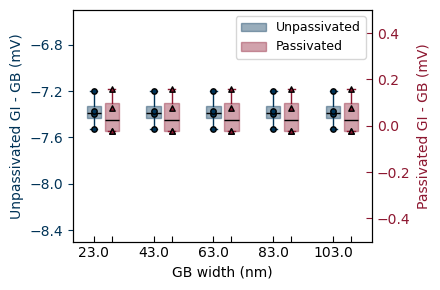

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

x_nm = [20, 40, 60, 80, 100]

np.random.seed(42) # Ensures the same data is generated every time
num_points = len(x_nm) # 5 points per dataset
num_datasets = 4 # Unpass1 through Unpass4

# --- 3. Generate Unpassivated Dummy Data (Simulating Unpass1, Unpass2, Unpass3, Unpass4) ---
# Goal: Cluster around -7.5 mV with low standard deviation (0.2)
unpass_means = np.full(num_points, -7.5)
unpass_stds = np.full(num_points, 0.2)
unpass_raw_datasets = []

# Generate 4 distinct datasets
for _ in range(num_datasets):
    data = unpass_means + np.random.normal(0, unpass_stds)
    unpass_raw_datasets.append(list(data))
print(unpass_means, unpass_stds, unpass_raw_datasets)
# Unpack the generated lists into the variables used in your code



# --- 4. Generate Passivated Dummy Data (Simulating Pass1, Pass2, Pass3, Pass4) ---
# Goal: Cluster around 0.0 mV with very low standard deviation (0.1)
pass_means = np.full(num_points, 0.0)
pass_stds = np.full(num_points, 0.1)
pass_raw_datasets = []
# Generate 4 distinct datasets
for _ in range(num_datasets):
    data = pass_means + np.random.normal(0, pass_stds)
    pass_raw_datasets.append(list(data))

# Unpack the generated lists into the variables used in your code
Pass1, Pass2, Pass3, Pass4 = pass_raw_datasets

# --- Define Plotting Parameters and Colors ---
x_nm = [20, 40, 60, 80, 100]
figsize_x, figsize_y = 4.5, 3.0
tick_length = 4
legend_font = 9
base_font_size = 10
num_groups = len(x_nm)

Unpass_Color = '#003357' # Dark Navy Blue
Pass_Color = '#8D1730'   # Maroon/Dark Red
OPACITY = 0.4 # 40% opacity for box fill
SCATTER_SIZE = 15 # Size of individual data points


# --- Data Transposition ---
# Assuming these variables (unpass_boxplot_data, pass_boxplot_data) 
# hold the transposed raw data: 5 lists, each with 4 data points.

# --- Dummy Data Generation (used for demonstration) ---
# NOTE: Replace this section with your actual data unpacking/transposition logic
# if running this in your script.
np.random.seed(42)
unpass_raw_datasets = [np.full(5, -7.5) + np.random.normal(0, 0.2) for _ in range(4)]
pass_raw_datasets = [np.full(5, 0.0) + np.random.normal(0, 0.1) for _ in range(4)]
unpass_boxplot_data = list(zip(*unpass_raw_datasets))
pass_boxplot_data = list(zip(*pass_raw_datasets))
# --- End of Dummy Data ---


# --- Box Plot Positioning ---
group_width = 12
#group_positions = [i + 1 for i in range(num_groups)]
group_positions=x_nm
unpass_positions = [pos - group_width/4 for pos in group_positions]
pass_positions = [pos + group_width/4 for pos in group_positions]


# --- Dual Y-Axis Plotting ---
plt.figure(figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size})

# 1. Primary Axis (ax1) for Unpassivated Data (Left Y-Axis)
ax1 = plt.gca()
ax1.set_xlabel("GB width (nm)")
ax1.set_ylabel("Unpassivated GI - GB (mV)", color=Unpass_Color)
ax1.tick_params(axis='y', colors=Unpass_Color)
ax1.tick_params(axis='x', direction='in', length=tick_length)
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Plot Unpassivated Boxplots on ax1 (with 40% opacity)
box1 = ax1.boxplot(
    unpass_boxplot_data,
    positions=unpass_positions,
    widths=group_width/2.5,
    patch_artist=True,
    # SET OPACITY HERE (alpha=0.4)
    boxprops=dict(facecolor=Unpass_Color, color=Unpass_Color, alpha=OPACITY),
    whiskerprops=dict(color=Unpass_Color),
    capprops=dict(color=Unpass_Color),
    medianprops=dict(color='black'),
    showfliers=False # Hide standard outliers to plot custom scatter points
)
ax1.set_ylim(-8.5, -6.5)

# Set X-axis ticks
ax1.set_xticks(group_positions)
ax1.set_xticklabels(x_nm)
# 2. Secondary Axis (ax2) for Passivated Data (Right Y-Axis)
ax2 = ax1.twinx()
ax2.set_ylabel("Passivated GI - GB (mV)", color=Pass_Color)
ax2.tick_params(axis='y', colors=Pass_Color)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.tick_params(direction='in', length=tick_length)

# Plot Passivated Boxplots on ax2 (with 40% opacity)
box2 = ax2.boxplot(
    pass_boxplot_data,
    positions=pass_positions,
    widths=group_width/2.5,
    patch_artist=True,
    # SET OPACITY HERE (alpha=0.4)
    boxprops=dict(facecolor=Pass_Color, color=Pass_Color, alpha=OPACITY),
    whiskerprops=dict(color=Pass_Color),
    capprops=dict(color=Pass_Color),
    medianprops=dict(color='black'),
    showfliers=False # Hide standard outliers to plot custom scatter points
)
ax2.set_ylim(-0.5, 0.5)


# --- Scatter Point Overlay (The new addition) ---
# Iterate over the 5 GB width groups (i)
for i in range(num_groups):
    # Plot Unpassivated points on ax1 (Shifted left)
    # The x-coordinate for all 4 points in this group is unpass_positions[i]
    x_scatter_unpass = [unpass_positions[i]] * len(unpass_boxplot_data[i])
    ax1.scatter(
        x_scatter_unpass, 
        unpass_boxplot_data[i], 
        color=Unpass_Color, 
        marker='o', # Circle marker
        s=SCATTER_SIZE, 
        edgecolor='black',
        zorder=3 # Ensure points are plotted above the box
    )

    # Plot Passivated points on ax2 (Shifted right)
    # The x-coordinate for all 4 points in this group is pass_positions[i]
    x_scatter_pass = [pass_positions[i]] * len(pass_boxplot_data[i])
    ax2.scatter(
        x_scatter_pass, 
        pass_boxplot_data[i], 
        color=Pass_Color, 
        marker='^', # Triangle marker
        s=SCATTER_SIZE, 
        edgecolor='black',
        zorder=3 # Ensure points are plotted above the box
    )


# --- Legend ---
# Create custom legend handles. The scatter points don't need to be in the main legend.
legend_handles = [
    Patch(facecolor=Unpass_Color, edgecolor=Unpass_Color, alpha=OPACITY, label='Unpassivated'),
    Patch(facecolor=Pass_Color, edgecolor=Pass_Color, alpha=OPACITY, label='Passivated')
]
plt.legend(handles=legend_handles, loc='upper right', fontsize=legend_font)

plt.tight_layout()
plt.show()